# Measures of Central Tendency

Central tendency describes **where data is centred** — the single value that best represents the entire dataset. The three measures are mean, median, and mode, each appropriate for different situations.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Mean — Arithmetic Average

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

- Sum all values and divide by count
- Uses every data point equally
- **Sensitive to outliers** — a single extreme value can pull the mean far from typical values
- Best for: symmetric distributions with no extreme outliers

In [2]:
print("Mean values:")
for col in ['age', 'fare', 'sibsp', 'parch']:
    print(f"  {col:10s}: {df[col].mean():.3f}")

Mean values:
  age       : 29.699
  fare      : 32.204
  sibsp     : 0.523
  parch     : 0.382


In [3]:
# Demonstrate outlier sensitivity of mean
normal_salaries = [50_000, 52_000, 48_000, 51_000, 49_000]
with_ceo = normal_salaries + [5_000_000]

print("Normal group — mean: {:,.0f}".format(np.mean(normal_salaries)))
print("With CEO salary — mean: {:,.0f}".format(np.mean(with_ceo)))
print("With CEO salary — median: {:,.0f}".format(np.median(with_ceo)))
print()
print("The mean jumps dramatically; the median barely moves.")

Normal group — mean: 50,000
With CEO salary — mean: 875,000
With CEO salary — median: 50,500

The mean jumps dramatically; the median barely moves.


## Median — Middle Value

The value that splits the sorted dataset in half — 50% of observations are below, 50% above.

- **Robust to outliers** — extreme values don't affect it
- Best for: skewed distributions (income, house prices, fare)
- Equal to the 50th percentile / Q2

In [4]:
print("Median values:")
for col in ['age', 'fare', 'sibsp', 'parch']:
    print(f"  {col:10s}: {df[col].median():.3f}")

print()
print("Fare — mean vs median:")
print(f"  Mean:   {df['fare'].mean():.2f}")
print(f"  Median: {df['fare'].median():.2f}")
print("  Mean > Median → right-skewed distribution")

Median values:
  age       : 28.000
  fare      : 14.454
  sibsp     : 0.000
  parch     : 0.000

Fare — mean vs median:
  Mean:   32.20
  Median: 14.45
  Mean > Median → right-skewed distribution


## Mode — Most Frequent Value

The value that appears most often in the dataset.

- The only central tendency measure valid for **categorical** data
- A dataset can have multiple modes (bimodal, multimodal)
- Useful for: finding the most common category, imputing missing categorical values

In [5]:
print("Mode values:")
for col in ['age', 'fare', 'pclass', 'sex', 'embarked']:
    mode_val = df[col].mode()[0]
    print(f"  {col:12s}: {mode_val}")

Mode values:
  age         : 24.0
  fare        : 8.05
  pclass      : 3
  sex         : male
  embarked    : S


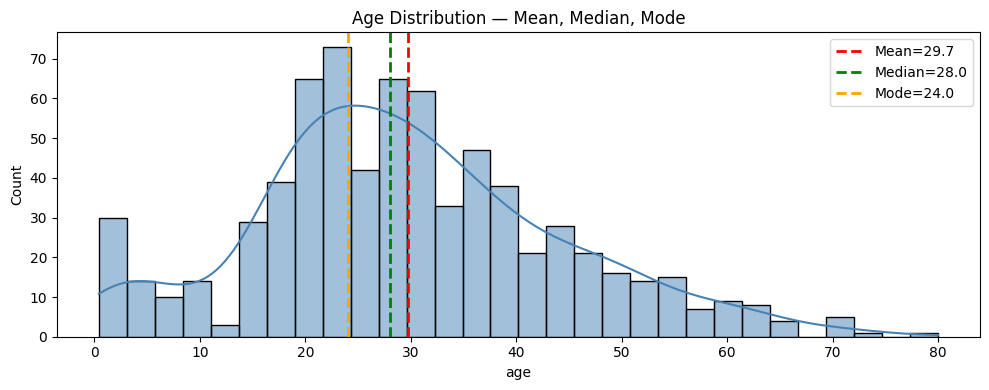

In [6]:
# Bimodal example — age distribution has two bumps
plt.figure(figsize=(10, 4))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='steelblue')
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={df["age"].mean():.1f}')
plt.axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median={df["age"].median():.1f}')
plt.axvline(df['age'].mode()[0], color='orange', linestyle='--', linewidth=2, label=f'Mode={df["age"].mode()[0]:.1f}')
plt.title('Age Distribution — Mean, Median, Mode')
plt.legend()
plt.tight_layout()
plt.show()

## Comparing All Three on Skewed vs Symmetric Data

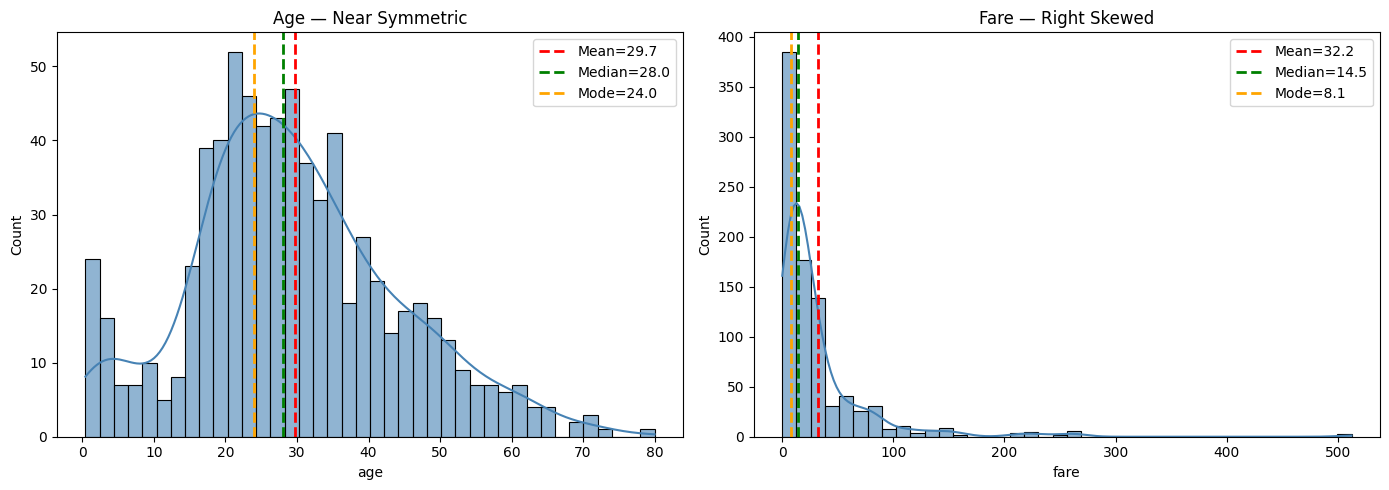

Symmetric: Mean ≈ Median ≈ Mode
Right-skewed: Mean > Median > Mode  (mean pulled toward the long tail)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'age',  'Age — Near Symmetric'),
    (axes[1], 'fare', 'Fare — Right Skewed')
]:
    data = df[col].dropna()
    sns.histplot(data, bins=40, kde=True, ax=ax, color='steelblue', alpha=0.6)
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=2, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='green',  linestyle='--', lw=2, label=f'Median={data.median():.1f}')
    ax.axvline(data.mode()[0],color='orange', linestyle='--', lw=2, label=f'Mode={data.mode()[0]:.1f}')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

print("Symmetric: Mean ≈ Median ≈ Mode")
print("Right-skewed: Mean > Median > Mode  (mean pulled toward the long tail)")

## Summary

| Measure | Formula | Sensitive to outliers? | Best for |
|---|---|---|---|
| **Mean** | sum / count | Yes | Symmetric distributions |
| **Median** | middle value | No | Skewed distributions |
| **Mode** | most frequent | No | Categorical data; multimodal data |

**Decision rule**: check skewness first. If |skewness| > 1, prefer median over mean.